In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# =========================================================
# 1. SAFE LOADER WITH AUTO-FALLBACKS
# =========================================================
def load_and_validate_csv(path, required_cols=None):
    """
    Load CSV, clean column names, and check/repair required columns.
    """
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=True)

    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]

        # Try auto-fixing specific cases
        if "discount_percent" in missing:
            if "original_price" in df.columns and "discounted_price" in df.columns:
                df["discount_percent"] = (
                    (df["original_price"] - df["discounted_price"]) / df["original_price"] * 100
                ).round(2)
                print(f"[INFO] Computed missing 'discount_percent' in {path}")
                missing.remove("discount_percent")

        if "discounted_price" in missing:
            if "original_price" in df.columns and "discount_percent" in df.columns:
                df["discounted_price"] = df["original_price"] * (1 - df["discount_percent"] / 100)
                print(f"[INFO] Computed missing 'discounted_price' in {path}")
                missing.remove("discounted_price")

        if missing:
            print(f"[WARNING] {path} is missing columns: {missing}. Proceeding anyway.")

    return df

In [ ]:
# =========================================================
# 2. FORECASTING PIPELINE WITH REGRESSORS
# =========================================================
def run_pipeline(enhanced_path, predicted_path):
    # Define expected schemas
    required_main = [
        "user_pseudo_id", "event_name", "event_date", "country", "region", "city",
        "item_id", "item_name", "item_category", "original_price", "discount_percent",
        "discounted_price", "quantity", "item_revenue", "converted",
        "days_since_first_event", "user_product_interaction_count",
        "user_product_view_count", "user_product_purchase_count",
        "campaign_type", "channel", "hour_of_day", "day_of_week"
    ]

    required_pred = [
        "original_price", "discount_percent", "item_category", "campaign_type", "channel",
        "hour_of_day", "day_of_week", "days_since_first_event",
        "user_product_view_count", "user_product_purchase_count", "user_product_interaction_count",
        "user_activity_count", "item_popularity", "conversion_probability",
        "converted_predicted", "user_pseudo_id", "item_id"
    ]

    # Load datasets
    df = load_and_validate_csv(enhanced_path, required_cols=required_main)
    pred = load_and_validate_csv(predicted_path, required_cols=required_pred)

    # Make sure event_date is datetime
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

    # Aggregate GMV + regressors daily
    daily = (
        df.groupby("event_date")
          .agg({
              "item_revenue": "sum",
              "discount_percent": "mean",
              "user_product_view_count": "sum",
              "user_product_purchase_count": "sum",
              "campaign_type": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
              "channel": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
          })
          .reset_index()
    )

    # Encode categorical regressors
    daily = pd.get_dummies(daily, columns=["campaign_type", "channel"], drop_first=True)

    # Prepare for Prophet
    daily.rename(columns={"event_date": "ds", "item_revenue": "y"}, inplace=True)

    # Build Prophet with regressors
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    for col in daily.columns:
        if col not in ["ds", "y"]:
            model.add_regressor(col)

    # Train
    model.fit(daily)

    # Forecast future
    future = model.make_future_dataframe(periods=14)  # forecast 14 days ahead
    future = future.merge(daily.drop(columns="y"), on="ds", how="left")

    # Fill missing future regressor values with last observed (simplest assumption)
    future.fillna(method="ffill", inplace=True)

    forecast = model.predict(future)

    # Merge actual vs forecast
    merged = pd.merge(daily[["ds", "y"]], forecast[["ds", "yhat"]], on="ds", how="left")

    # Weekly aggregation
    weekly_actual = daily.resample("W-MON", on="ds").sum().reset_index()
    weekly_forecast = forecast[["ds", "yhat"]].resample("W-MON", on="ds").sum().reset_index()

    # Evaluation metrics
    def eval_metrics(actual, pred):
        mae = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        mape = np.mean(np.abs((actual - pred) / actual)) * 100
        smape = 100 * np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred)))
        wmape = 100 * np.sum(np.abs(actual - pred)) / np.sum(actual)
        return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "wMAPE": wmape}

    daily_metrics = eval_metrics(merged["y"], merged["yhat"])
    weekly_metrics = eval_metrics(weekly_actual["y"], weekly_forecast["yhat"])

    # Print metrics
    print("\n📊 Prophet Daily Forecast Evaluation with Regressors:")
    for k, v in daily_metrics.items():
        print(f"   {k:<5}= {v:.2f}")

    print("\n📊 Prophet Weekly Forecast Evaluation with Regressors:")
    for k, v in weekly_metrics.items():
        print(f"   {k:<5}= {v:.2f}")

    # Plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Daily
    axes[0].plot(merged["ds"], merged["y"], label="Actual GMV", marker="o")
    axes[0].plot(merged["ds"], merged["yhat"], label="Forecast (Regressors)", marker="x")
    axes[0].set_title("Prophet Daily GMV Forecast (with Regressors)")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("GMV")
    axes[0].legend()

    # Weekly
    axes[1].plot(weekly_actual["ds"], weekly_actual["y"], label="Weekly Actual", marker="o")
    axes[1].plot(weekly_forecast["ds"], weekly_forecast["yhat"], label="Weekly Forecast", marker="x")
    axes[1].set_title("Prophet Weekly GMV Forecast (with Regressors)")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("GMV")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    # =========================================================
    # 3. BUSINESS-USEFULNESS EXTENSIONS
    # =========================================================

    # 3.1 Discount Elasticity
    def run_discount_elasticity(model, daily, forecast, shocks=[-20, -10, 0, 10, 20, 50]):
        results = []
        base = forecast["yhat"].mean()
        for s in shocks:
            future = daily.copy()
            future["discount_percent"] = future["discount_percent"] * (1 + s / 100)
            preds = model.predict(future.drop(columns=["y"]))
            shocked_gmv = preds["yhat"].mean()
            uplift = ((shocked_gmv - base) / base) * 100
            results.append({"Shock": f"{s:+}%", "GMV_Uplift(%)": uplift})
        return pd.DataFrame(results)

    elasticity_df = run_discount_elasticity(model, daily, forecast)
    print("\n🔎 Discount Elasticity Results:\n", elasticity_df)

    # 3.2 Campaign ROI
    def campaign_roi_analysis(df):
        roi = (
            df.groupby("campaign_type")
              .agg({"item_revenue": "sum", "discount_percent": "mean"})
              .reset_index()
        )
        roi["GMV_per_Discount"] = roi["item_revenue"] / roi["discount_percent"].replace(0, np.nan)
        return roi.sort_values("GMV_per_Discount", ascending=False)

    campaign_results = campaign_roi_analysis(df)
    print("\n📢 Campaign ROI Analysis:\n", campaign_results)

    # 3.3 Channel Effectiveness
    def channel_effectiveness(df):
        res = (
            df.groupby("channel")
              .agg({"item_revenue": "sum", "discount_percent": "mean"})
              .reset_index()
        )
        res["GMV_per_Discount"] = res["item_revenue"] / res["discount_percent"].replace(0, np.nan)
        return res.sort_values("GMV_per_Discount", ascending=False)

    channel_results = channel_effectiveness(df)
    print("\n📡 Channel Effectiveness:\n", channel_results)

    # 3.4 Price Sensitivity Segments
    def price_sensitivity_segments(df):
        seg = (
            df.groupby("item_category")
              .agg({"item_revenue": "sum", "discount_percent": "mean"})
              .reset_index()
        )
        seg["Elasticity"] = seg["item_revenue"] / seg["discount_percent"].replace(0, np.nan)
        return seg.sort_values("Elasticity", ascending=False)

    segment_results = price_sensitivity_segments(df)
    print("\n🛒 Price Sensitivity Segments:\n", segment_results)

    return model, daily_metrics, weekly_metrics, merged, forecast, elasticity_df, campaign_results, channel_results, segment_results



INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyz978o78/ir0z49by.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyz978o78/8_u9dkx8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27567', 'data', 'file=/tmp/tmpyz978o78/ir0z49by.json', 'init=/tmp/tmpyz978o78/8_u9dkx8.json', 'output', 'file=/tmp/tmpyz978o78/prophet_model7af09pkf/prophet_model-20250930093224.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
09:32:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:32:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/tmp/ipython-input-456667638.py:64: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj


📊 Prophet Daily Forecast Evaluation with Regressors:
   MAE  = 2002.72
   RMSE = 2515.86
   MAPE = 7.31
   SMAPE= 7.23
   wMAPE= 7.09

📊 Prophet Weekly Forecast Evaluation with Regressors:
   MAE  = 4720.12
   RMSE = 5521.44
   MAPE = 2.66
   SMAPE= 2.64
   wMAPE= 2.51


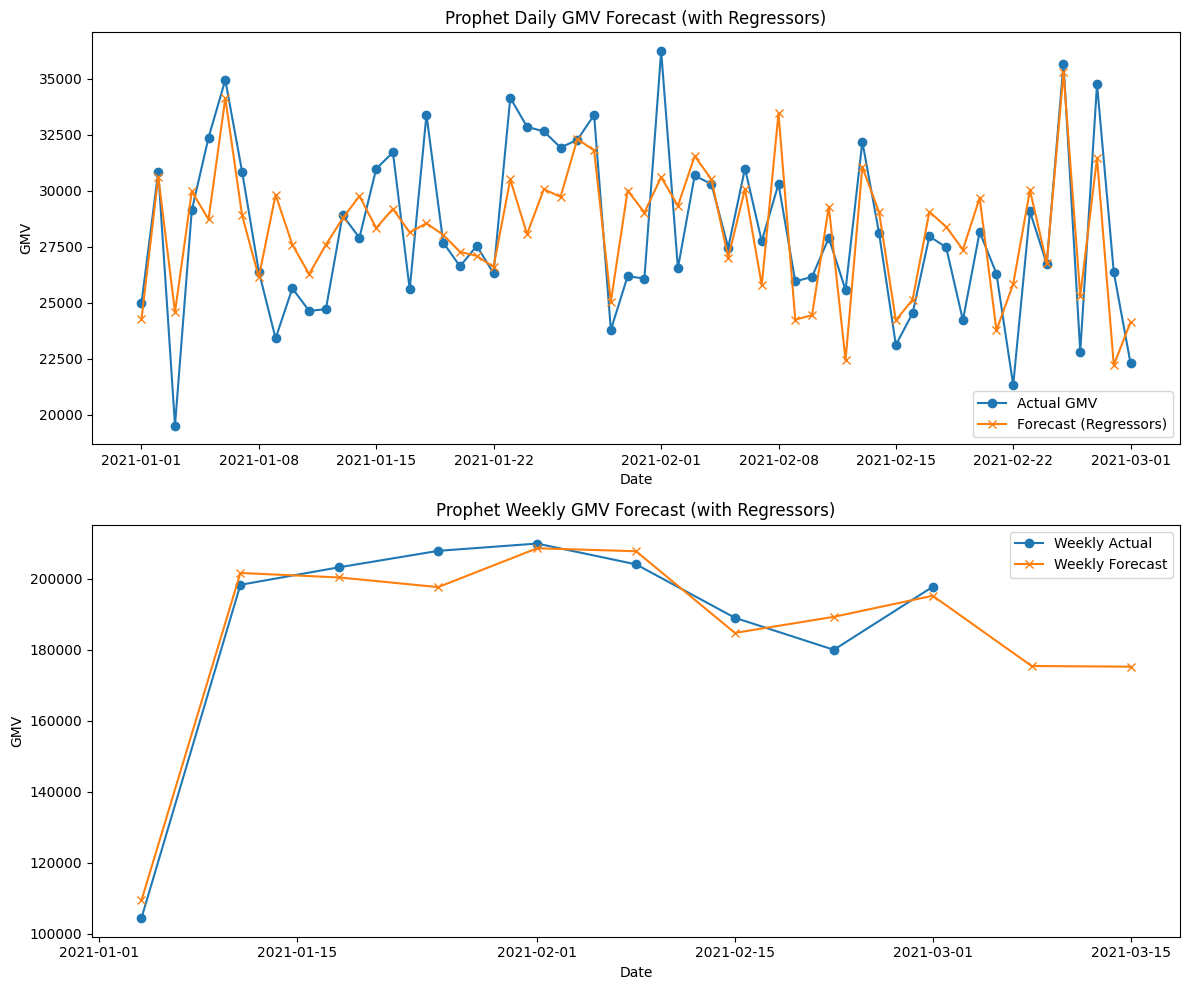


🔎 Discount Elasticity Results:
   Shock  GMV_Uplift(%)
0  -20%      16.316154
1  -10%       9.251758
2   +0%       2.187363
3  +10%      -4.877033
4  +20%     -11.941428
5  +50%     -33.134615

📢 Campaign ROI Analysis:
              campaign_type  item_revenue  discount_percent  GMV_per_Discount
1        Category-Specific     609919.31         23.012123      26504.261312
0  Abandoned Cart Recovery     285448.75         22.937115      12444.841213
2         First-Time Buyer     271798.06         23.239419      11695.561682
3               Flash Sale     267784.74         23.300767      11492.529100
4                  Generic     259592.73         23.036953      11268.535838

📡 Channel Effectiveness:
              channel  item_revenue  discount_percent  GMV_per_Discount
3           Referral     359140.74         23.478649      15296.482053
0              Email     348585.29         22.836338      15264.500097
4       Social Media     339863.81         22.915452      14831.206976
2  Pus

In [ ]:
# =========================================================
# 4. RUN MAIN
# =========================================================
if __name__ == "__main__":
    model, daily_res, weekly_res, merged, forecast, elasticity_df, campaign_results, channel_results, segment_results = run_pipeline(
        enhanced_path="enhanced_synthetic_discount_dataset.csv",
        predicted_path="predicted_conversions.csv",
    )